<a href="https://colab.research.google.com/github/JorgeMarquezPiedra/Temperatura-Humedad-Relativa-Direccion-y-Velocidad-del-Viento-Ciudad-de-Mexico-2015-a-2023-Python/blob/main/Mediciones_Meteorologicasipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Red Meteorológica

In [1]:
# Cargar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
# Leer dataset
redmet = pd.read_csv("redmet_2023_05.csv")
redmet

,fecha,RH,TMP,WDR,WSP
0,2015-01-01,60.565476,13.385714,156.723039,1.933333
1,2015-01-02,52.452381,13.567262,176.710784,2.559804
2,2015-01-03,55.763636,13.893333,190.830846,2.136318
3,2015-01-04,62.776786,12.536012,196.306373,2.592647
4,2015-01-05,70.271845,9.070227,266.889764,2.963517
...,...,...,...,...,...
3068,2023-05-27,51.899130,19.453565,190.198664,2.187646
3069,2023-05-28,59.949565,17.375826,183.542571,2.092154
3070,2023-05-29,58.837743,17.039153,169.527919,1.952284
3071,2023-05-30,50.145719,18.684699,184.998255,1.978709


##La Red de Meteorología y Radiación Solar (REDMET) es el subsistema del Sistema de Monitoreo Atmosférico de la Ciudad de México (SIMAT) que realiza mediciones continuas y permanentes minuto a minuto de temperatura (TMP), humedad relativa (RH), dirección del viento (WDR) y la velocidad del viento (WSP)

In [3]:
# Información del dataset
redmet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3073 entries, 0 to 3072
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   fecha   3073 non-null   object 
 1   RH      3073 non-null   float64
 2   TMP     3073 non-null   float64
 3   WDR     3073 non-null   float64
 4   WSP     3073 non-null   float64
dtypes: float64(4), object(1)
memory usage: 120.2+ KB


In [4]:
# Pasar columna fecha a formato datetime
redmet["fecha"] = pd.to_datetime(redmet["fecha"])
redmet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3073 entries, 0 to 3072
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   fecha   3073 non-null   datetime64[ns]
 1   RH      3073 non-null   float64       
 2   TMP     3073 non-null   float64       
 3   WDR     3073 non-null   float64       
 4   WSP     3073 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 120.2 KB


In [5]:
# Crear columnas de año y mes
redmet["año"] = redmet["fecha"].dt.year
redmet["mes"] = redmet["fecha"].dt.month
redmet

,fecha,RH,TMP,WDR,WSP,año,mes
0,2015-01-01,60.565476,13.385714,156.723039,1.933333,2015,1
1,2015-01-02,52.452381,13.567262,176.710784,2.559804,2015,1
2,2015-01-03,55.763636,13.893333,190.830846,2.136318,2015,1
3,2015-01-04,62.776786,12.536012,196.306373,2.592647,2015,1
4,2015-01-05,70.271845,9.070227,266.889764,2.963517,2015,1
...,...,...,...,...,...,...,...
3068,2023-05-27,51.899130,19.453565,190.198664,2.187646,2023,5
3069,2023-05-28,59.949565,17.375826,183.542571,2.092154,2023,5
3070,2023-05-29,58.837743,17.039153,169.527919,1.952284,2023,5
3071,2023-05-30,50.145719,18.684699,184.998255,1.978709,2023,5


In [6]:
# Mapeo de meses para correción
mapeo_meses = {
    1: 'Enero',
    2: 'Febrero',
    3: 'Marzo',
    4: 'Abril',
    5: 'Mayo',
    6: 'Junio',
    7: 'Julio',
    8: 'Agosto',
    9: 'Septiembre',
    10: 'Octubre',
    11: 'Noviembre',
    12: 'Diciembre'
}

redmet['mes'] = redmet['mes'].map(mapeo_meses)
redmet

,fecha,RH,TMP,WDR,WSP,año,mes
0,2015-01-01,60.565476,13.385714,156.723039,1.933333,2015,Enero
1,2015-01-02,52.452381,13.567262,176.710784,2.559804,2015,Enero
2,2015-01-03,55.763636,13.893333,190.830846,2.136318,2015,Enero
3,2015-01-04,62.776786,12.536012,196.306373,2.592647,2015,Enero
4,2015-01-05,70.271845,9.070227,266.889764,2.963517,2015,Enero
...,...,...,...,...,...,...,...
3068,2023-05-27,51.899130,19.453565,190.198664,2.187646,2023,Mayo
3069,2023-05-28,59.949565,17.375826,183.542571,2.092154,2023,Mayo
3070,2023-05-29,58.837743,17.039153,169.527919,1.952284,2023,Mayo
3071,2023-05-30,50.145719,18.684699,184.998255,1.978709,2023,Mayo


In [7]:
# Crear días
# Mapear nombres de día en inglés a español
mapeo_dias = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

# Crear una nueva columna 'día_semana' con los nombres de los días en español
redmet['dia'] = redmet['fecha'].dt.day_name().map(mapeo_dias)
redmet

,fecha,RH,TMP,WDR,WSP,año,mes,dia
0,2015-01-01,60.565476,13.385714,156.723039,1.933333,2015,Enero,Jueves
1,2015-01-02,52.452381,13.567262,176.710784,2.559804,2015,Enero,Viernes
2,2015-01-03,55.763636,13.893333,190.830846,2.136318,2015,Enero,Sábado
3,2015-01-04,62.776786,12.536012,196.306373,2.592647,2015,Enero,Domingo
4,2015-01-05,70.271845,9.070227,266.889764,2.963517,2015,Enero,Lunes
...,...,...,...,...,...,...,...,...
3068,2023-05-27,51.899130,19.453565,190.198664,2.187646,2023,Mayo,Sábado
3069,2023-05-28,59.949565,17.375826,183.542571,2.092154,2023,Mayo,Domingo
3070,2023-05-29,58.837743,17.039153,169.527919,1.952284,2023,Mayo,Lunes
3071,2023-05-30,50.145719,18.684699,184.998255,1.978709,2023,Mayo,Martes


In [8]:
redmet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3073 entries, 0 to 3072
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   fecha   3073 non-null   datetime64[ns]
 1   RH      3073 non-null   float64       
 2   TMP     3073 non-null   float64       
 3   WDR     3073 non-null   float64       
 4   WSP     3073 non-null   float64       
 5   año     3073 non-null   int32         
 6   mes     3073 non-null   object        
 7   dia     3073 non-null   object        
dtypes: datetime64[ns](1), float64(4), int32(1), object(2)
memory usage: 180.2+ KB


##Histogramas

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

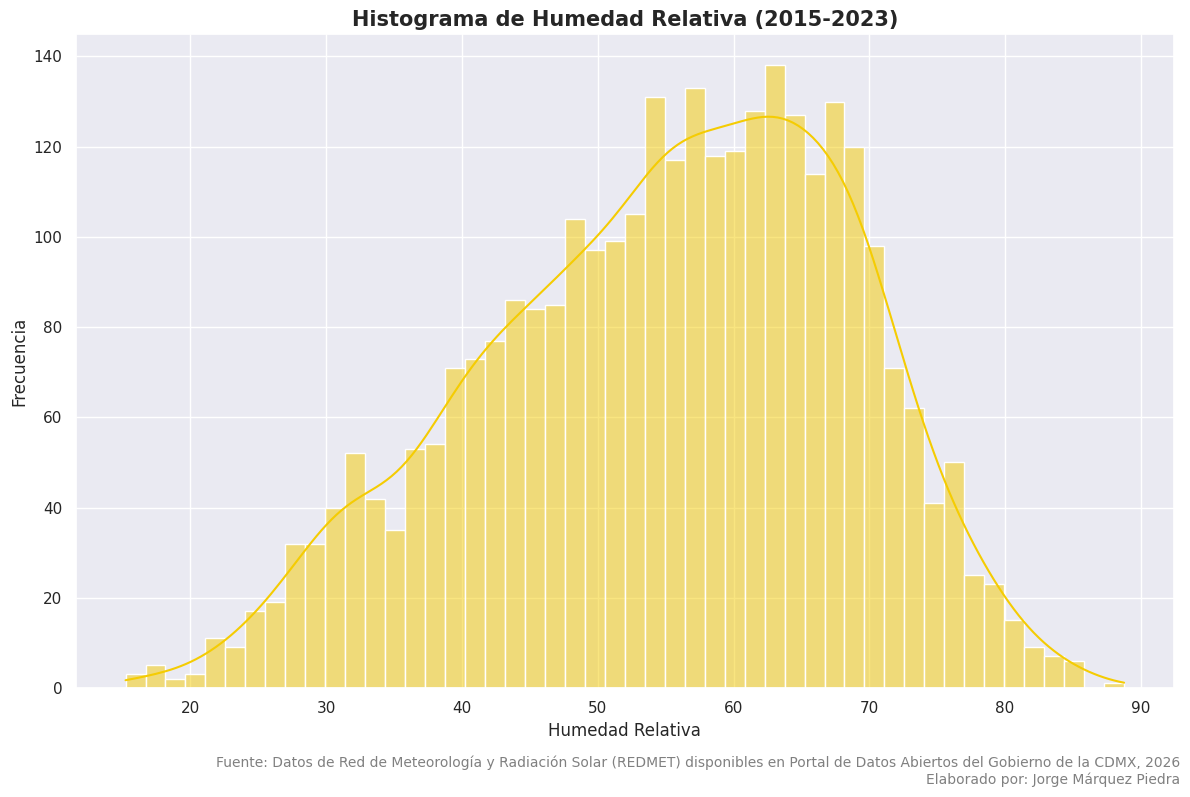

In [9]:
# Histograma de RH
plt.figure(figsize = (12, 8))
sns.set_theme()
sns.histplot(redmet['RH'], bins = 50, kde = True, color = '#f5cc02')
plt.title('Histograma de Humedad Relativa (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Humedad Relativa')
plt.ylabel('Frecuencia')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.13)
plt.savefig('histograma_humedad.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

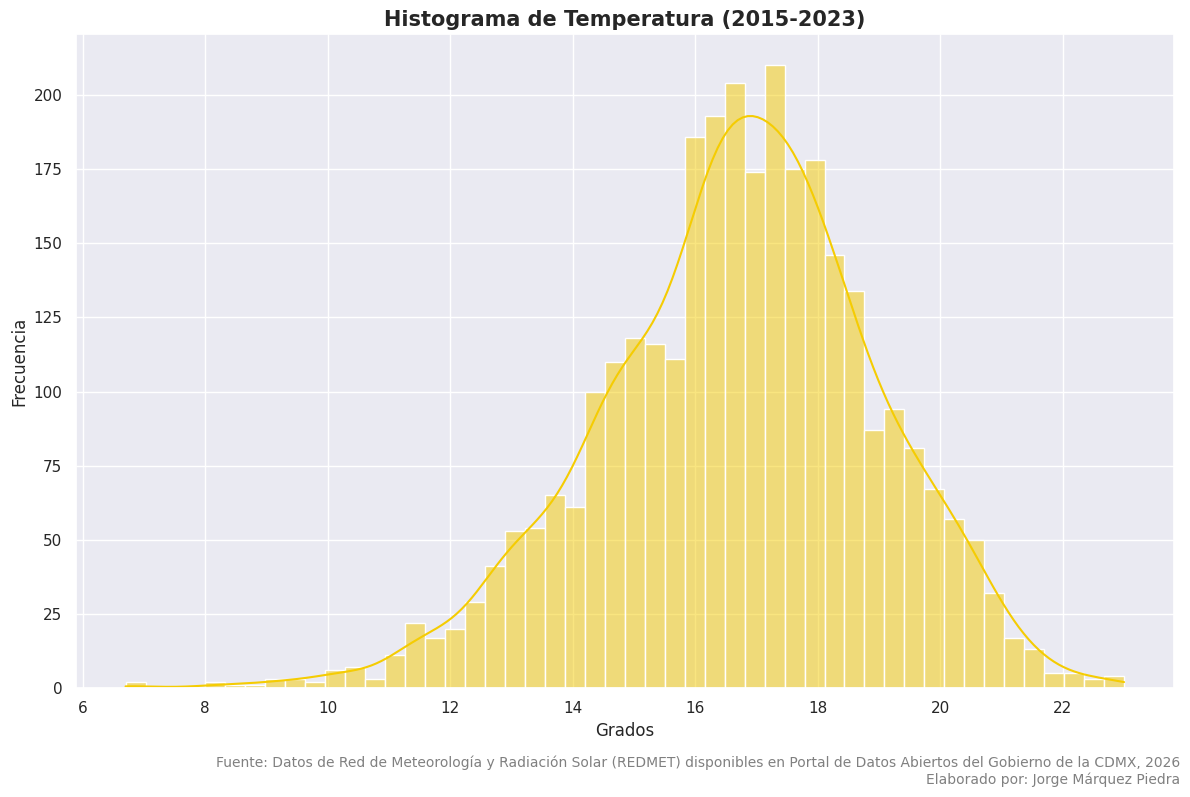

In [10]:
# Histograma de TMP
plt.figure(figsize = (12, 8))
sns.set_theme()
sns.histplot(redmet['TMP'], bins = 50, kde = True, color = '#f5cc02')
plt.title('Histograma de Temperatura (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Grados')
plt.ylabel('Frecuencia')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.13)
plt.savefig('histograma_temp.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

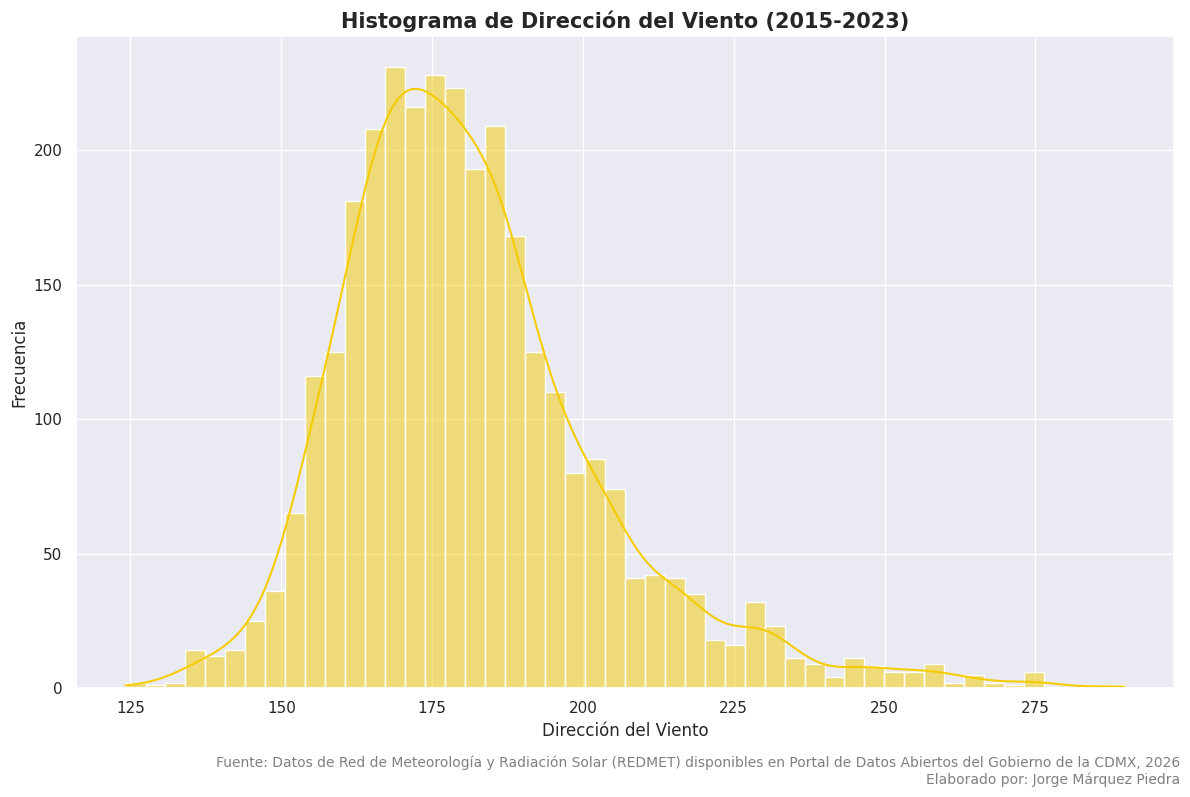

In [11]:
# Histograma de WDR
plt.figure(figsize = (12, 8))
sns.set_theme()
sns.histplot(redmet['WDR'], bins = 50, kde = True, color = '#f5cc02')
plt.title('Histograma de Dirección del Viento (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Dirección del Viento')
plt.ylabel('Frecuencia')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.13)
plt.savefig('histograma_direccion_viento.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

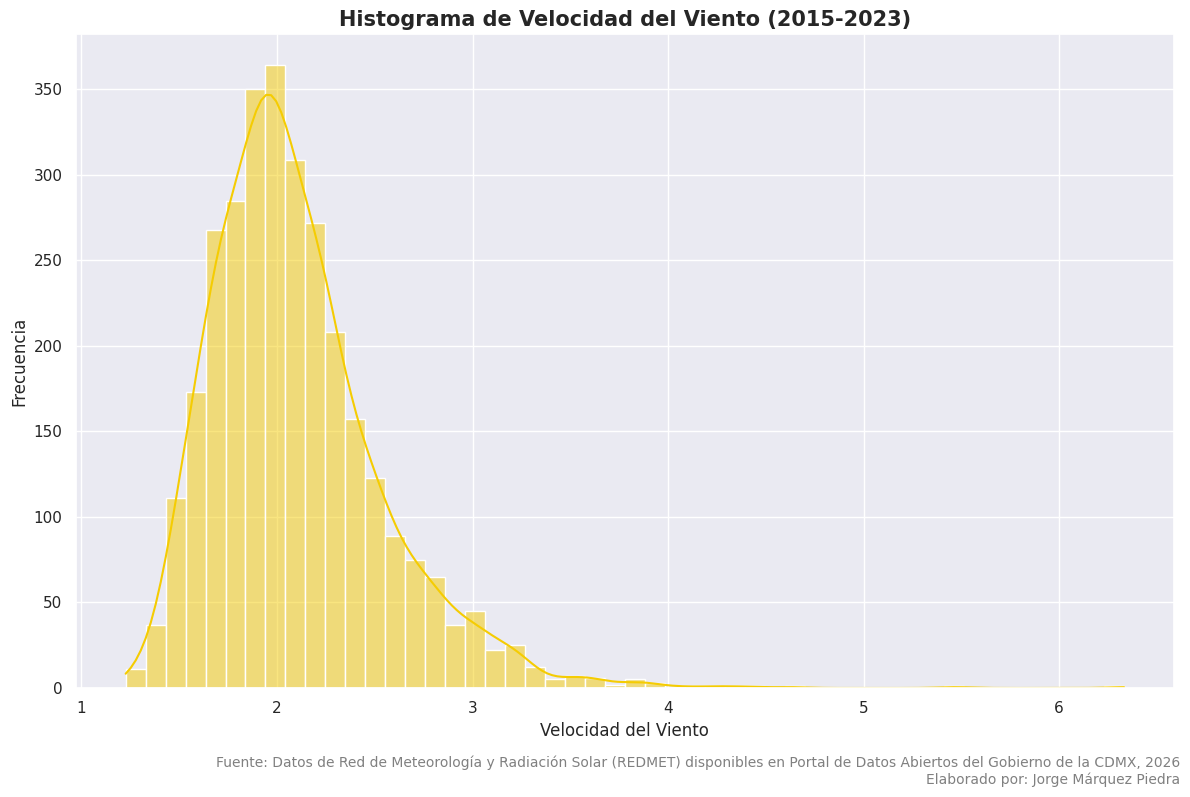

In [12]:
# Histograma de WDS
plt.figure(figsize = (12, 8))
sns.set_theme()
sns.histplot(redmet['WSP'], bins = 50, kde = True, color = '#f5cc02')
plt.title('Histograma de Velocidad del Viento (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Velocidad del Viento')
plt.ylabel('Frecuencia')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.13)
plt.savefig('histograma_velocidad_viento.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

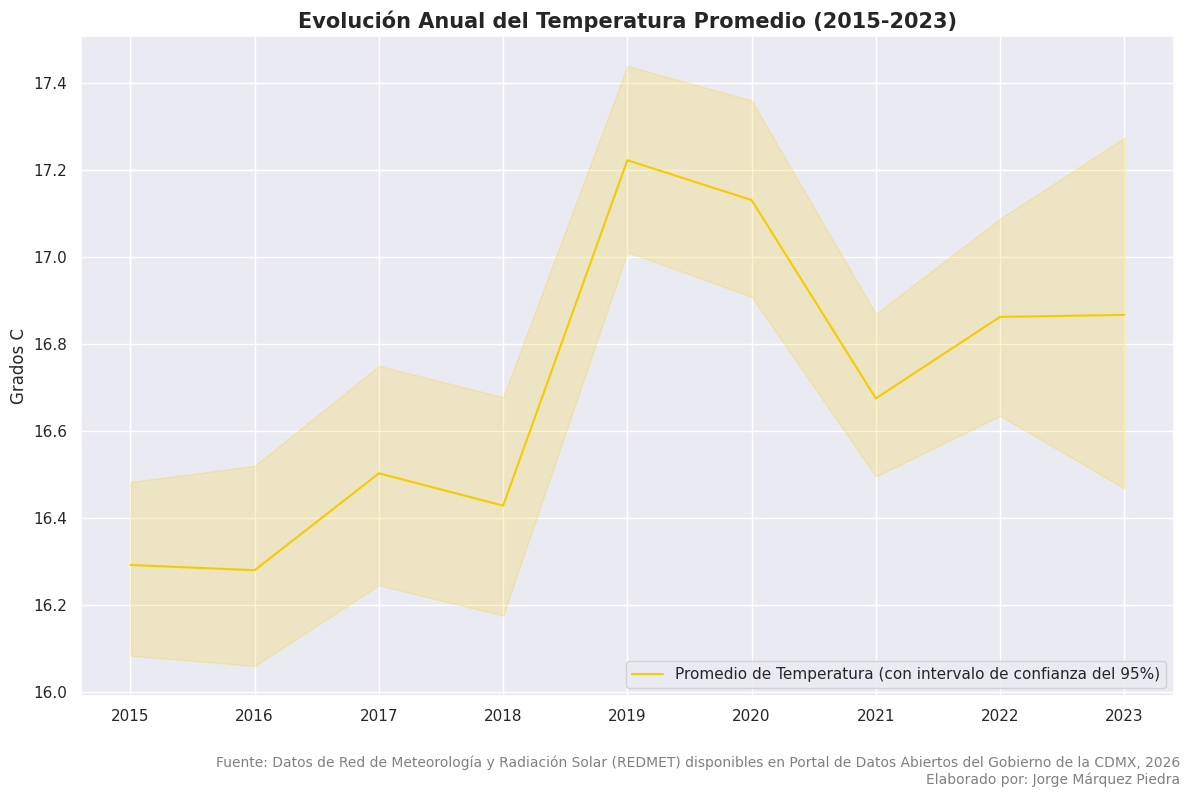

In [13]:
plt.figure(figsize = (12,8))
sns.set_theme()
sns.lineplot(data = redmet, x = 'año', y = 'TMP', color = '#f5cc02', label = 'Promedio de Temperatura (con intervalo de confianza del 95%)')
plt.title('Evolución Anual del Temperatura Promedio (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Grados C')
plt.xticks()
plt.legend(loc = 'lower right')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('evolucion_temporal_temp.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

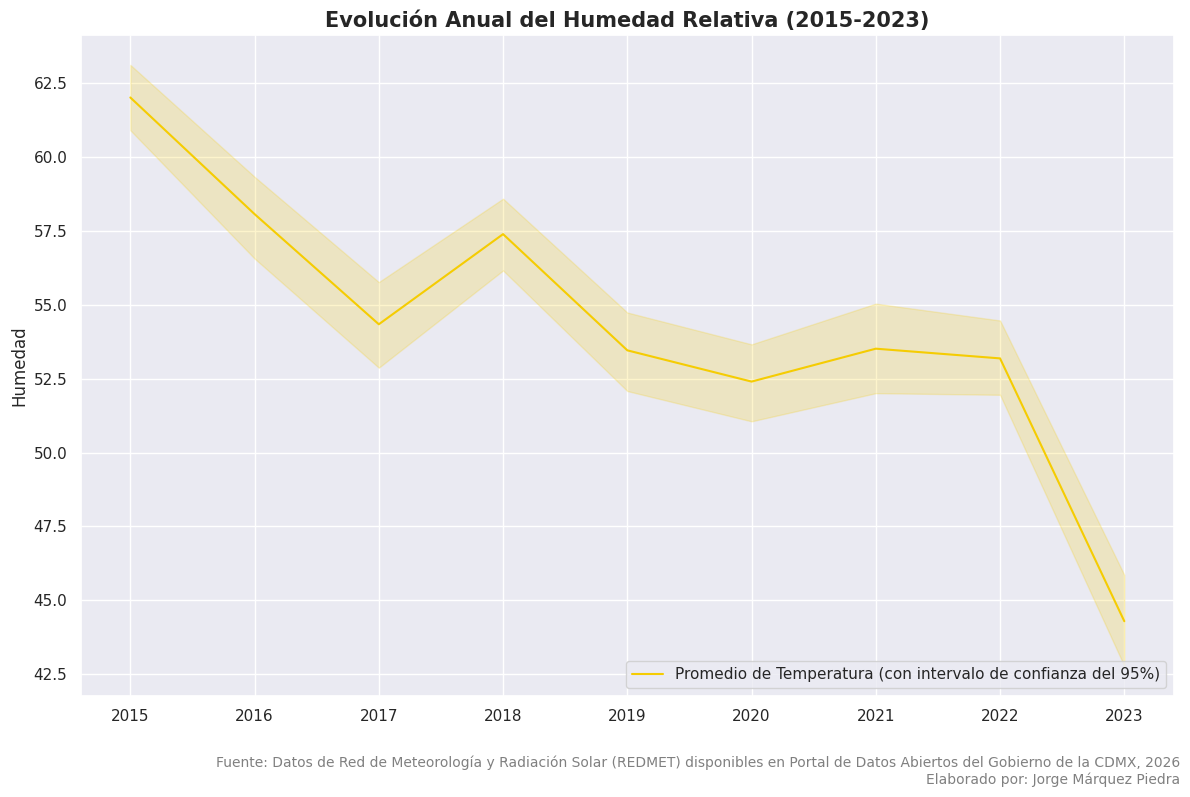

In [14]:
plt.figure(figsize = (12,8))
sns.set_theme()
sns.lineplot(data = redmet, x = 'año', y = 'RH', color = '#f5cc02', label = 'Promedio de Temperatura (con intervalo de confianza del 95%)')
plt.title('Evolución Anual del Humedad Relativa (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Humedad')
plt.xticks()
plt.legend(loc = 'lower right')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('evolucion_temporal_humedad_r.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

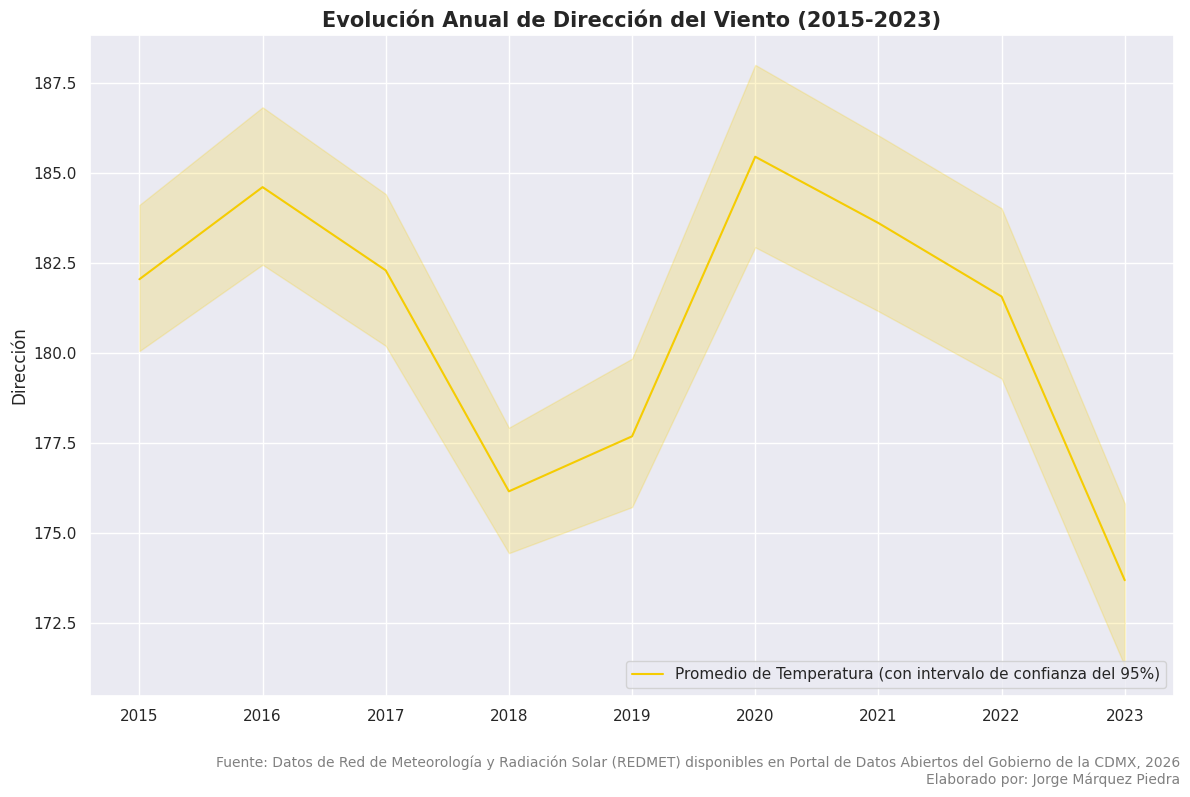

In [15]:
plt.figure(figsize = (12,8))
sns.set_theme()
sns.lineplot(data = redmet, x = 'año', y = 'WDR', color = '#f5cc02', label = 'Promedio de Temperatura (con intervalo de confianza del 95%)')
plt.title('Evolución Anual de Dirección del Viento (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Dirección')
plt.xticks()
plt.legend(loc = 'lower right')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('evolucion_temporal_direccion_viento.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

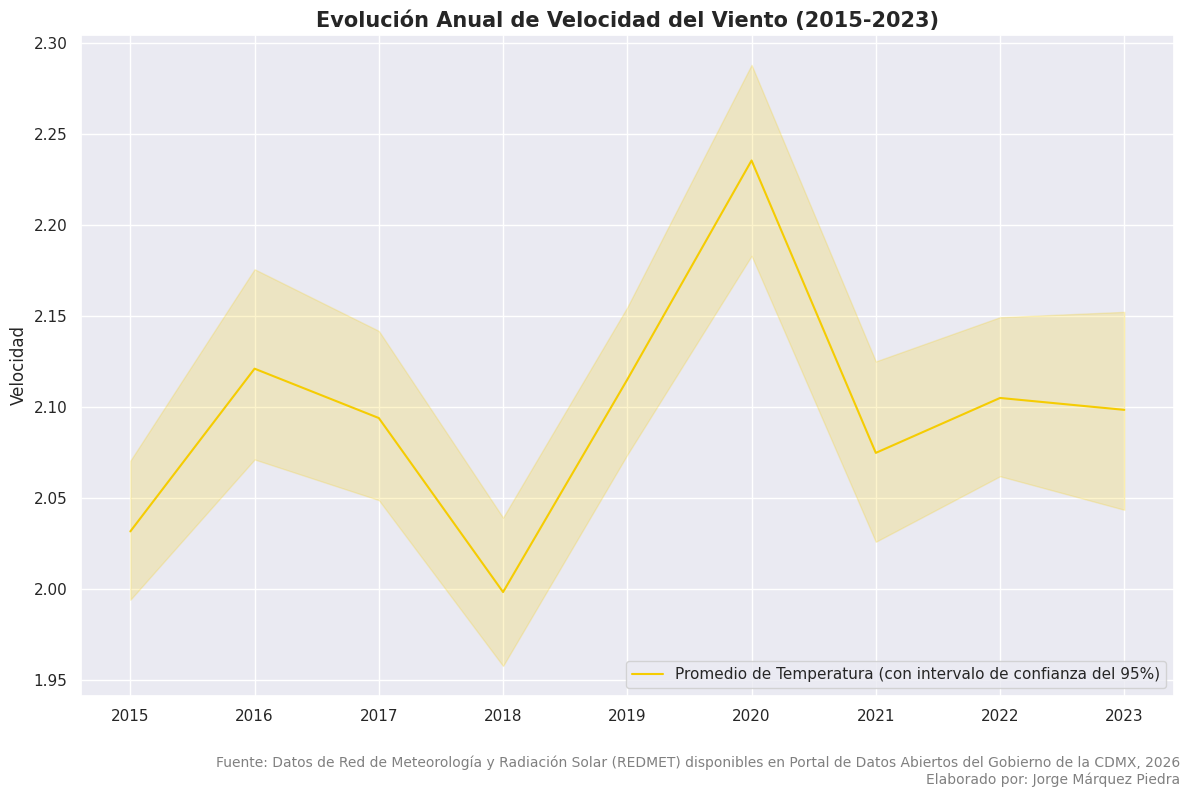

In [16]:
plt.figure(figsize = (12,8))
sns.set_theme()
sns.lineplot(data = redmet, x = 'año', y = 'WSP', color = '#f5cc02', label = 'Promedio de Temperatura (con intervalo de confianza del 95%)')
plt.title('Evolución Anual de Velocidad del Viento (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Velocidad')
plt.xticks()
plt.legend(loc = 'lower right')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('evolucion_temporal_velocidad_viento.png', dpi = 300)
plt

##Valores máximos y promedio

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

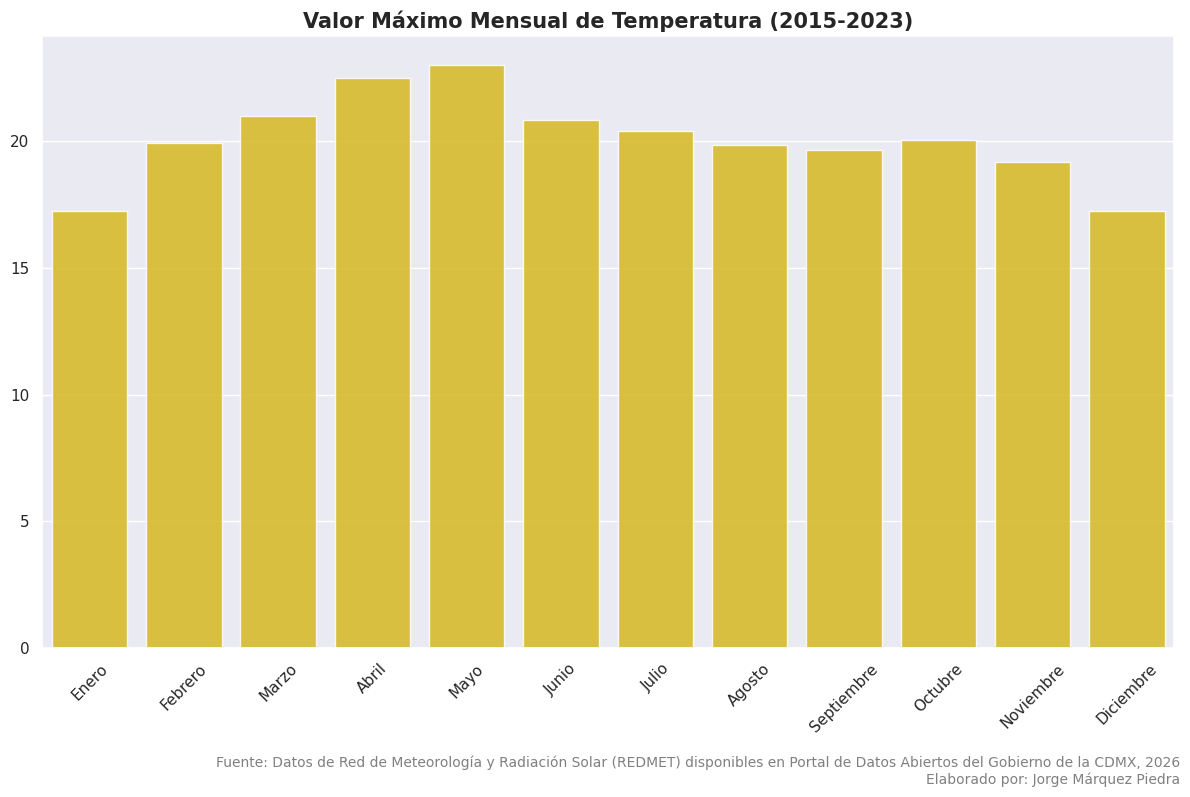

In [17]:
# Crear dataframe mensual
max_mes = redmet.groupby('mes')[['RH','TMP','WDR','WSP']].max().reset_index()

# Definir el orden correcto de dias
orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

# Ordenar el dataframe usando el orden de meses
max_mes['mes'] = pd.Categorical(max_mes['mes'], categories = orden_meses, ordered = True)
max_mes = max_mes.sort_values('mes')

# Temperatura máxima por mes
plt.figure(figsize = (12,8))
sns.barplot(data = max_mes, x = 'mes', y = 'TMP', color = '#f5cc02', alpha = 0.85, legend = False)
plt.title('Valor Máximo Mensual de Temperatura (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45)
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.18)
plt.savefig('temp_max_por_mes.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

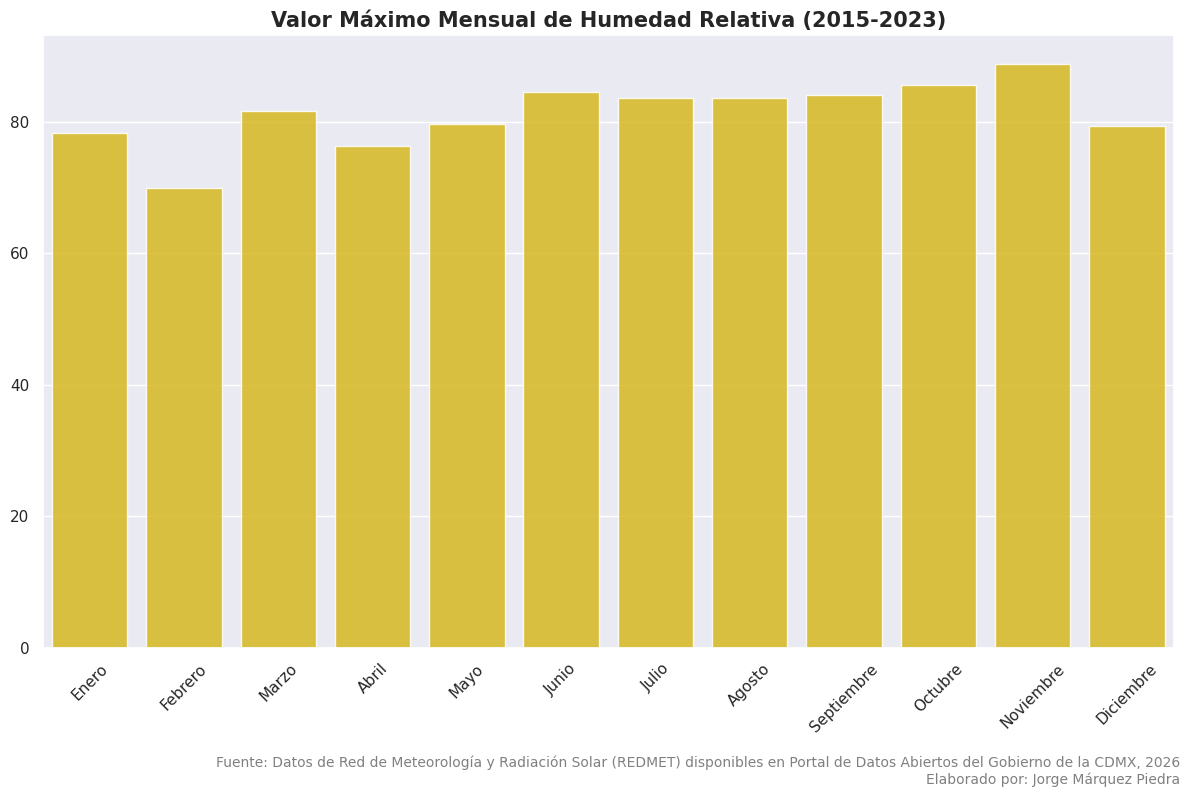

In [18]:
# Humedad relativa máxima por mes
plt.figure(figsize = (12,8))
sns.barplot(data = max_mes, x = 'mes', y = 'RH', color = '#f5cc02', alpha = 0.85, legend = False)
plt.title('Valor Máximo Mensual de Humedad Relativa (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45)
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.18)
plt.savefig('humedad_max_por_mes.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

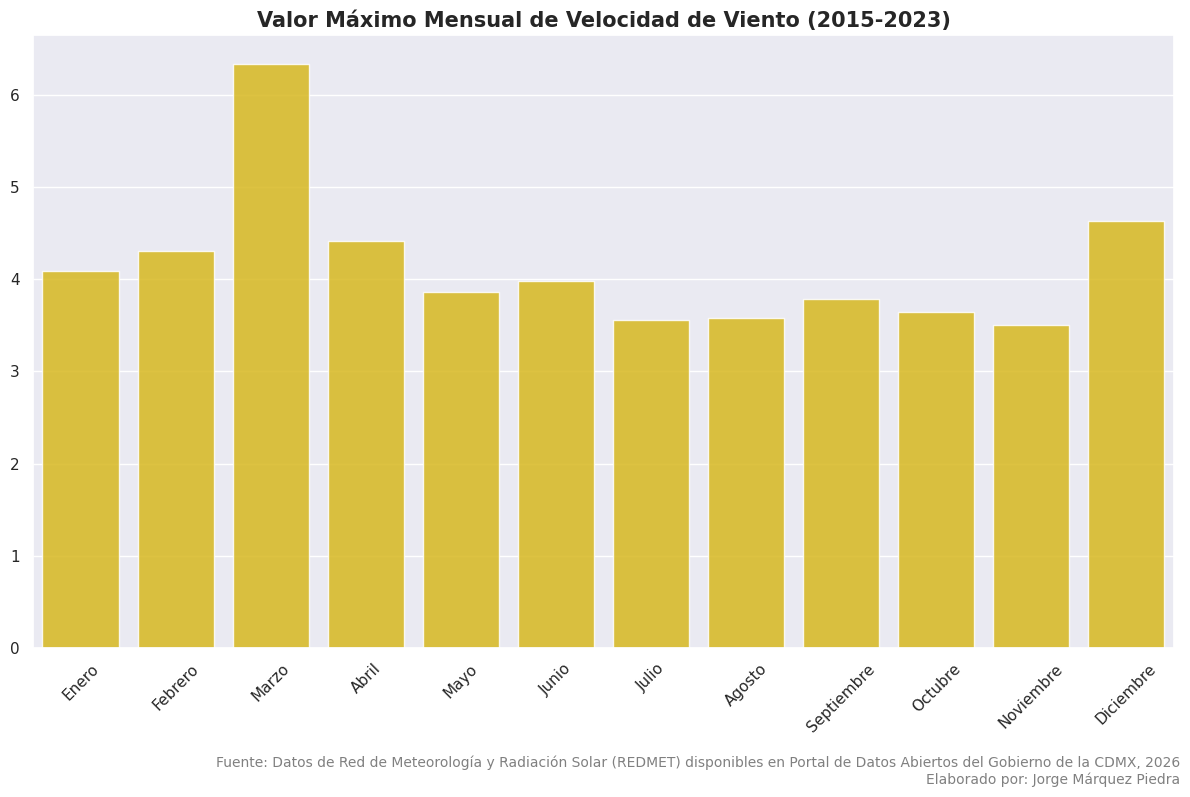

In [19]:
# Velocidad viento máxima por mes
plt.figure(figsize = (12,8))
sns.barplot(data = max_mes, x = 'mes', y = 'WSP', color = '#f5cc02', alpha = 0.85, legend = False)
plt.title('Valor Máximo Mensual de Velocidad de Viento (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45)
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.18)
plt.savefig('velocidad_viento_max_por_mes.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

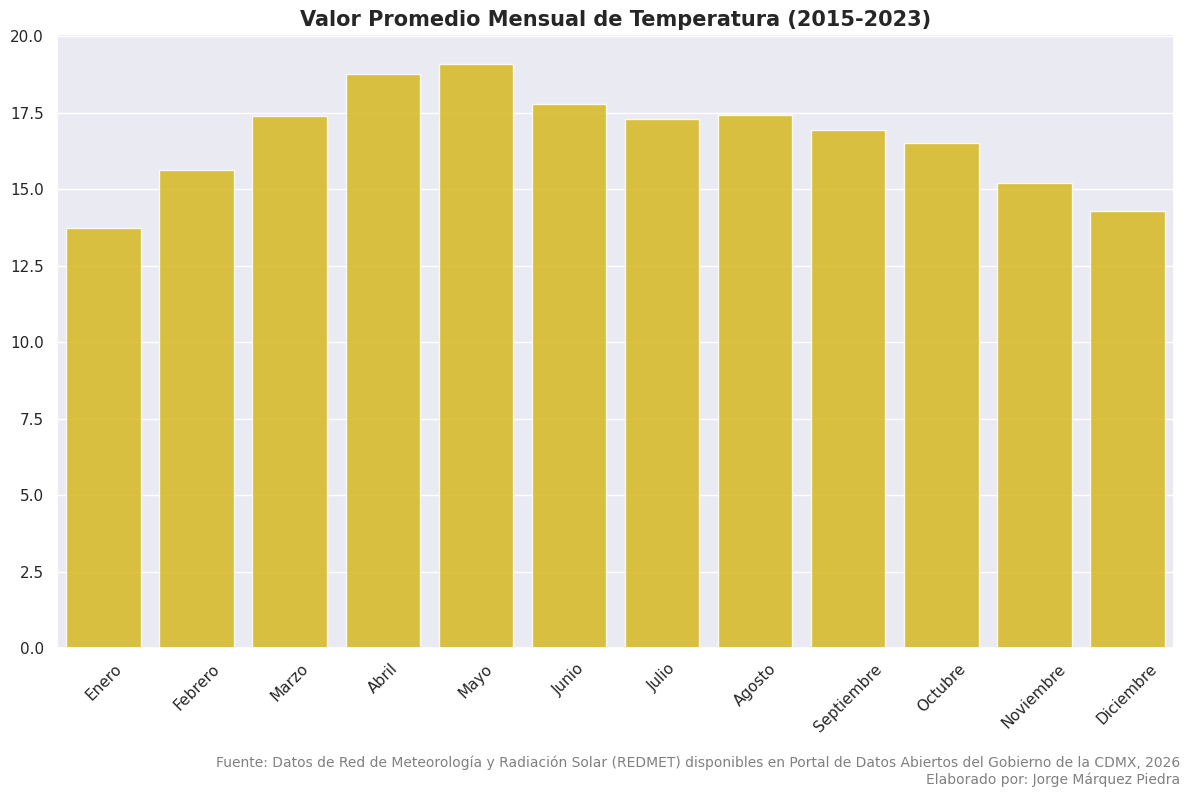

In [20]:
# Crear dataframe mensual
promedio_mes = redmet.groupby('mes')[['RH','TMP','WDR','WSP']].mean().reset_index()

# Ordenar el dataframe usando el orden de meses
promedio_mes['mes'] = pd.Categorical(promedio_mes['mes'], categories = orden_meses, ordered = True)
promedio_mes = promedio_mes.sort_values('mes')

# Temperatura promedio por mes
plt.figure(figsize = (12,8))
sns.barplot(data = promedio_mes, x = 'mes', y = 'TMP', color = '#f5cc02', alpha = 0.85, legend = False)
plt.title('Valor Promedio Mensual de Temperatura (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45)
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.18)
plt.savefig('temp_promedio_por_mes.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

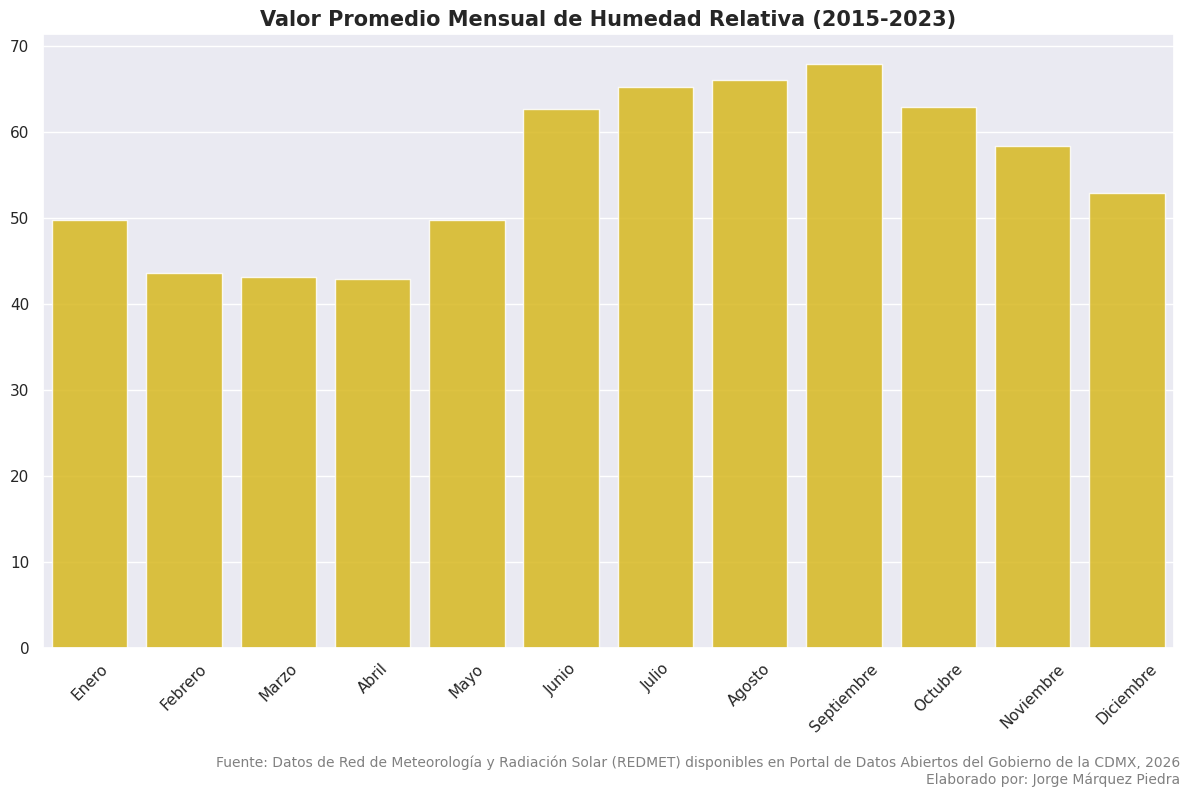

In [21]:
# Humedad relativa promedio por mes
plt.figure(figsize = (12,8))
sns.barplot(data = promedio_mes, x = 'mes', y = 'RH', color = '#f5cc02', alpha = 0.85, legend = False)
plt.title('Valor Promedio Mensual de Humedad Relativa (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45)
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.18)
plt.savefig('humedad_promedio_por_mes.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

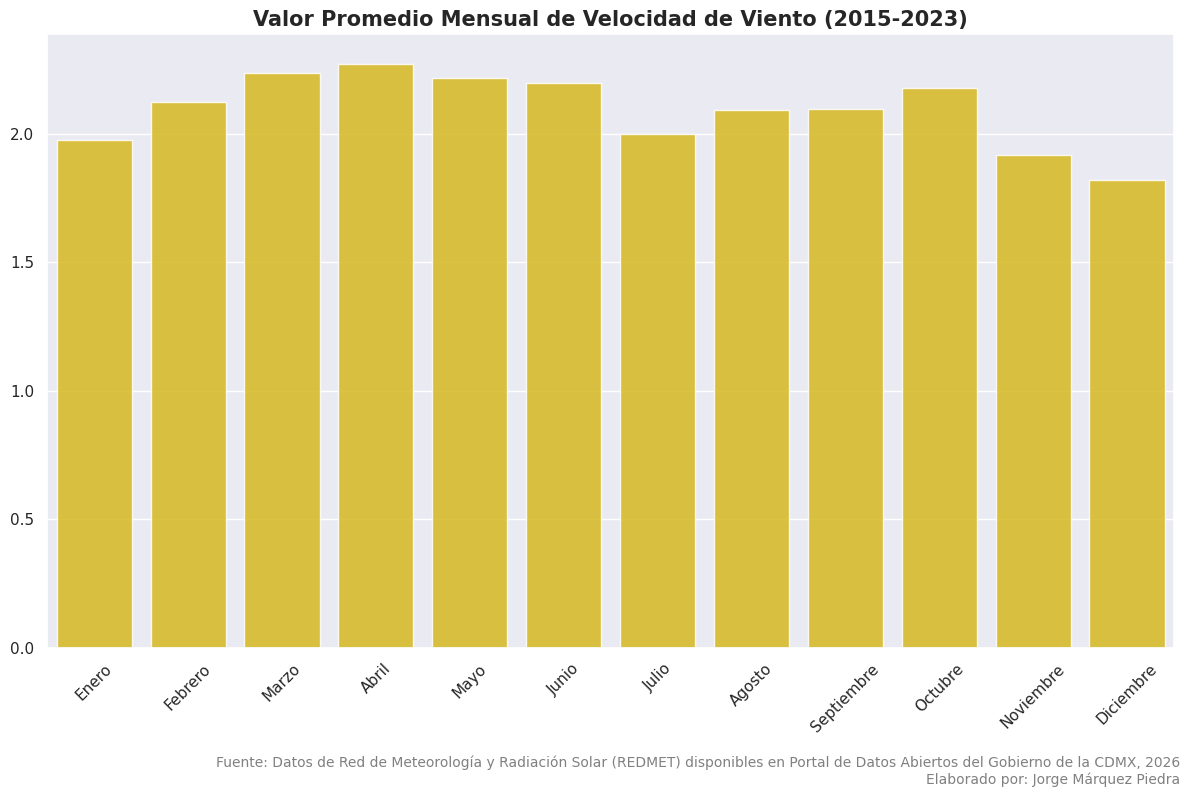

In [22]:
# Velocidad viento promedio por mes
plt.figure(figsize = (12,8))
sns.barplot(data = promedio_mes, x = 'mes', y = 'WSP', color = '#f5cc02', alpha = 0.85, legend = False)
plt.title('Valor Promedio Mensual de Velocidad de Viento (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45)
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.18)
plt.savefig('velocidad_viento_promedio_por_mes.png', dpi = 300)
plt

##Variabilidad de temperatura por mes y año

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

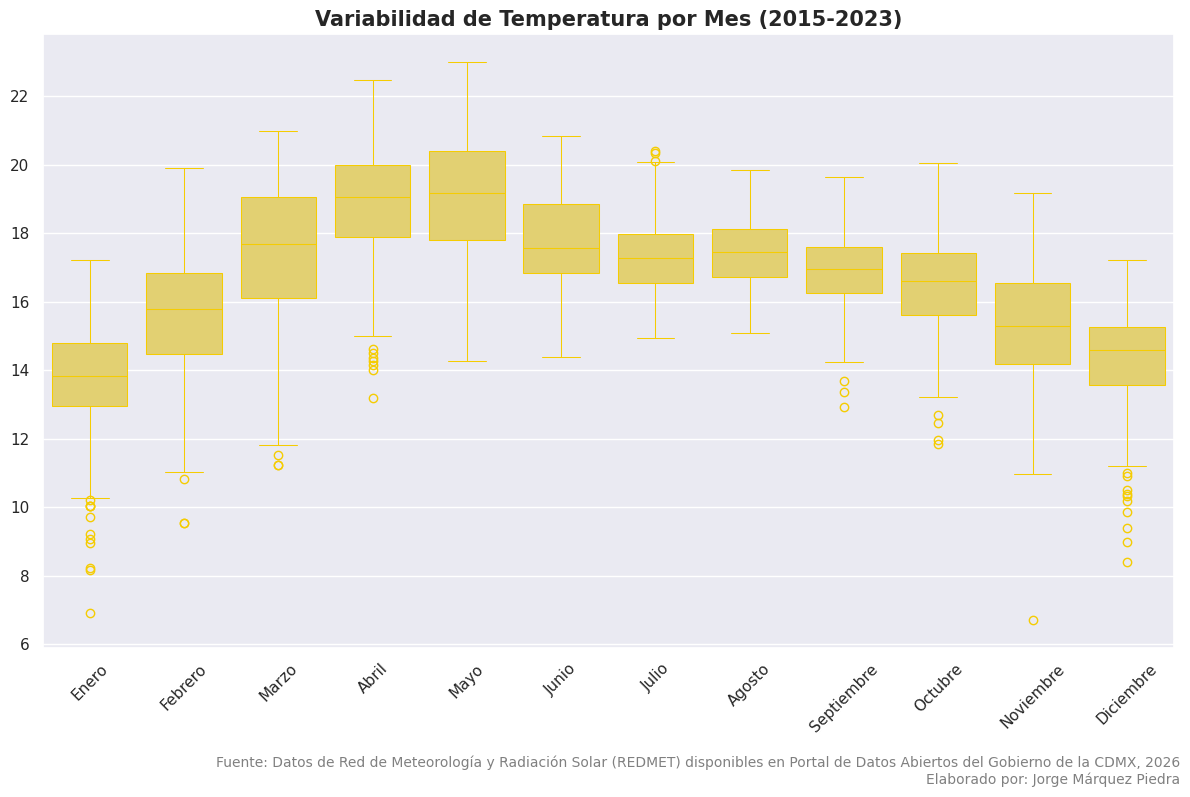

In [23]:
# Variabilidad de temperatura
plt.figure(figsize = (12,8))
sns.boxplot(data = redmet, x = 'mes', y = 'TMP', color = '#f5dc5f', linecolor="#f5cc02", linewidth=.75)
plt.title('Variabilidad de Temperatura por Mes (2015-2023)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45)
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.18)
plt.savefig('boxplot_temp_por_mes.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

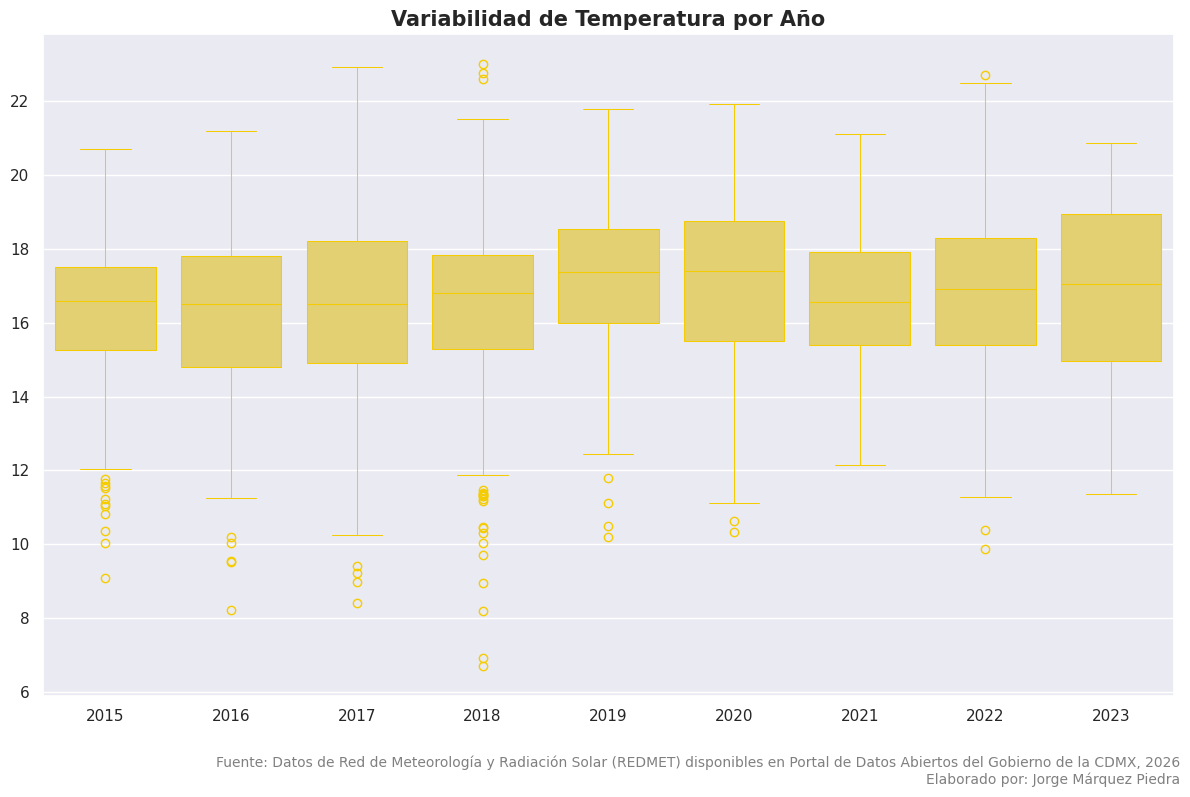

In [24]:
# Variabilidad de temperatura
plt.figure(figsize = (12,8))
sns.boxplot(data = redmet, x = 'año', y = 'TMP', color = '#f5dc5f', linecolor="#f5cc02", linewidth=.75)
plt.title('Variabilidad de Temperatura por Año', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks()
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('boxplot_temp_por_año.png', dpi = 300)
plt

##Correlación de variables

In [25]:
# Matriz de correlación
correlation_matrix = redmet[['TMP','RH','WDR','WSP']].corr()
print("Matriz de correlación:")
print(correlation_matrix)

Matriz de correlación:
          TMP        RH       WDR       WSP
TMP  1.000000 -0.260275 -0.219942  0.191692
RH  -0.260275  1.000000  0.217657 -0.184621
WDR -0.219942  0.217657  1.000000  0.219021
WSP  0.191692 -0.184621  0.219021  1.000000


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

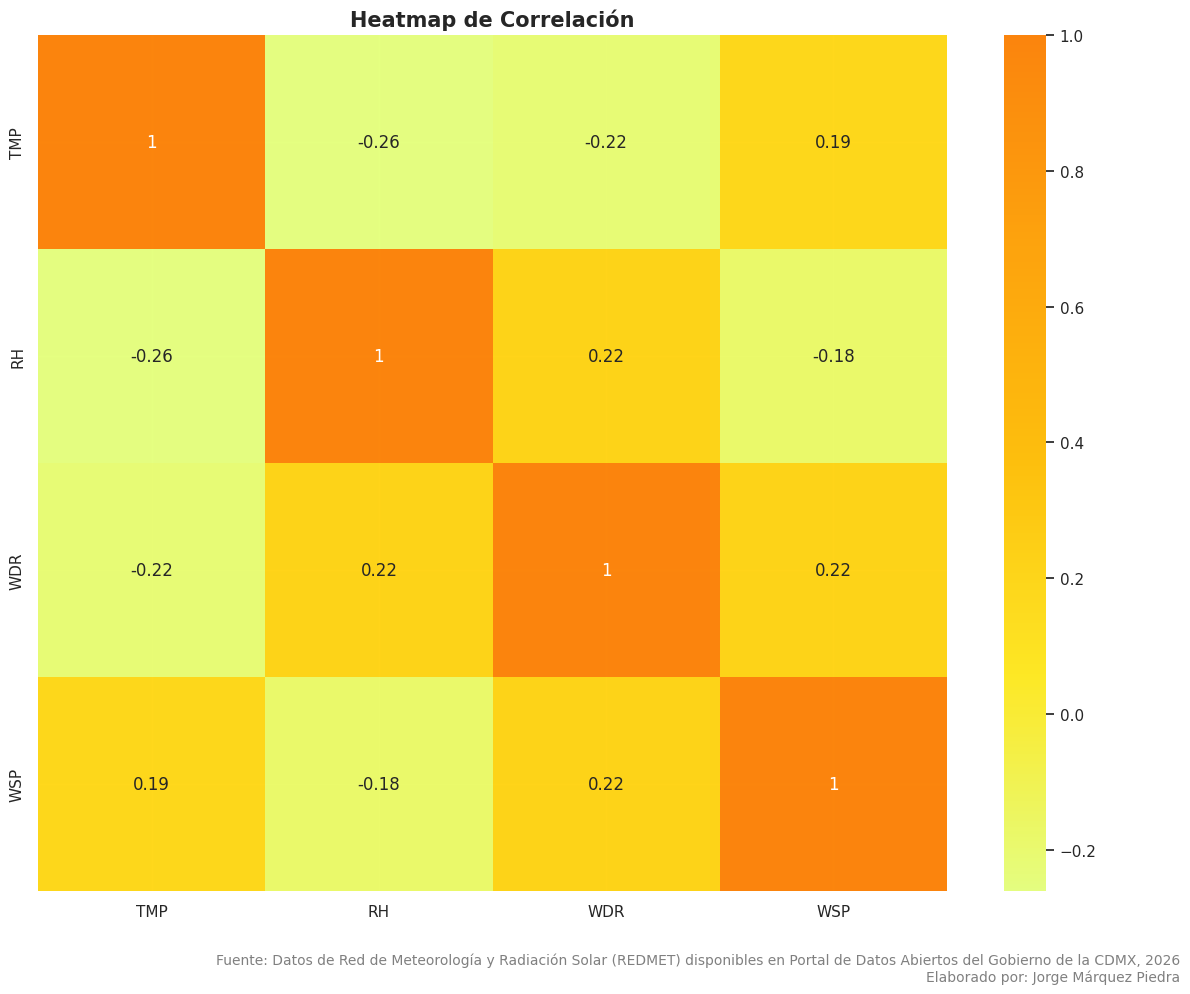

In [26]:
# Generar Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='Wistia', alpha = 0.95)
plt.title('Heatmap de Correlación', fontsize = 15, fontweight = 'bold')
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.10)
plt.savefig('matriz_correlacion.png', dpi = 300)
plt

/tmp/ipykernel_141/506130610.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SO', 'O', 'NO'])


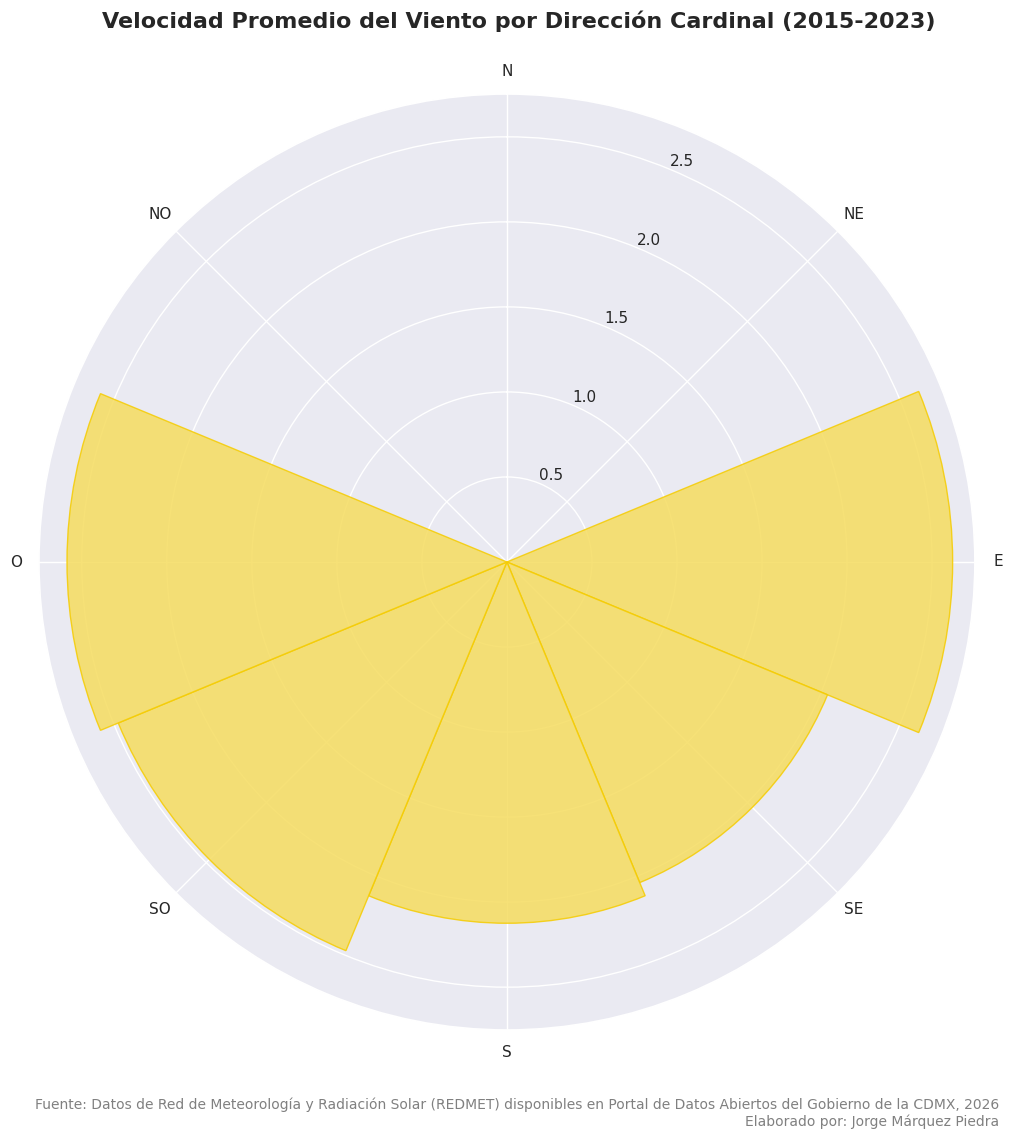

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Procesamiento de datos (Sectores de 45°)
direcciones = redmet['WDR']
velocidades = redmet['WSP']
bins = np.linspace(0, 360, 9)

hist, bin_edges = np.histogram(direcciones, bins=bins, weights=velocidades)
conteo, _ = np.histogram(direcciones, bins=bins)
promedio_velocidad = hist / np.where(conteo == 0, 1, conteo)

plt.figure(figsize=(12, 12))

# Eje polar centrado [izquierda, abajo, ancho, alto] en cantidades de 0 a 1
ax = plt.axes([0.18, 0.10, 0.8, 0.78], projection='polar')

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

# Barras
angles = np.deg2rad(bin_edges[:-1])
width = np.deg2rad(45)
bars = ax.bar(
    angles,
    promedio_velocidad,
    width=width,
    color='#f5dc5f',
    edgecolor='#f5cc02',
    alpha=0.85
)

plt.suptitle('Velocidad Promedio del Viento por Dirección Cardinal (2015-2023)',
             fontsize=16, fontweight='bold', x=0.59, y=0.95)

ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SO', 'O', 'NO'])

plt.figtext(0.99, 0.02,
            'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra',
            horizontalalignment='right', fontsize=10, color='gray')

plt.savefig('rosa_vientos.png', dpi=300, bbox_inches='tight')
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

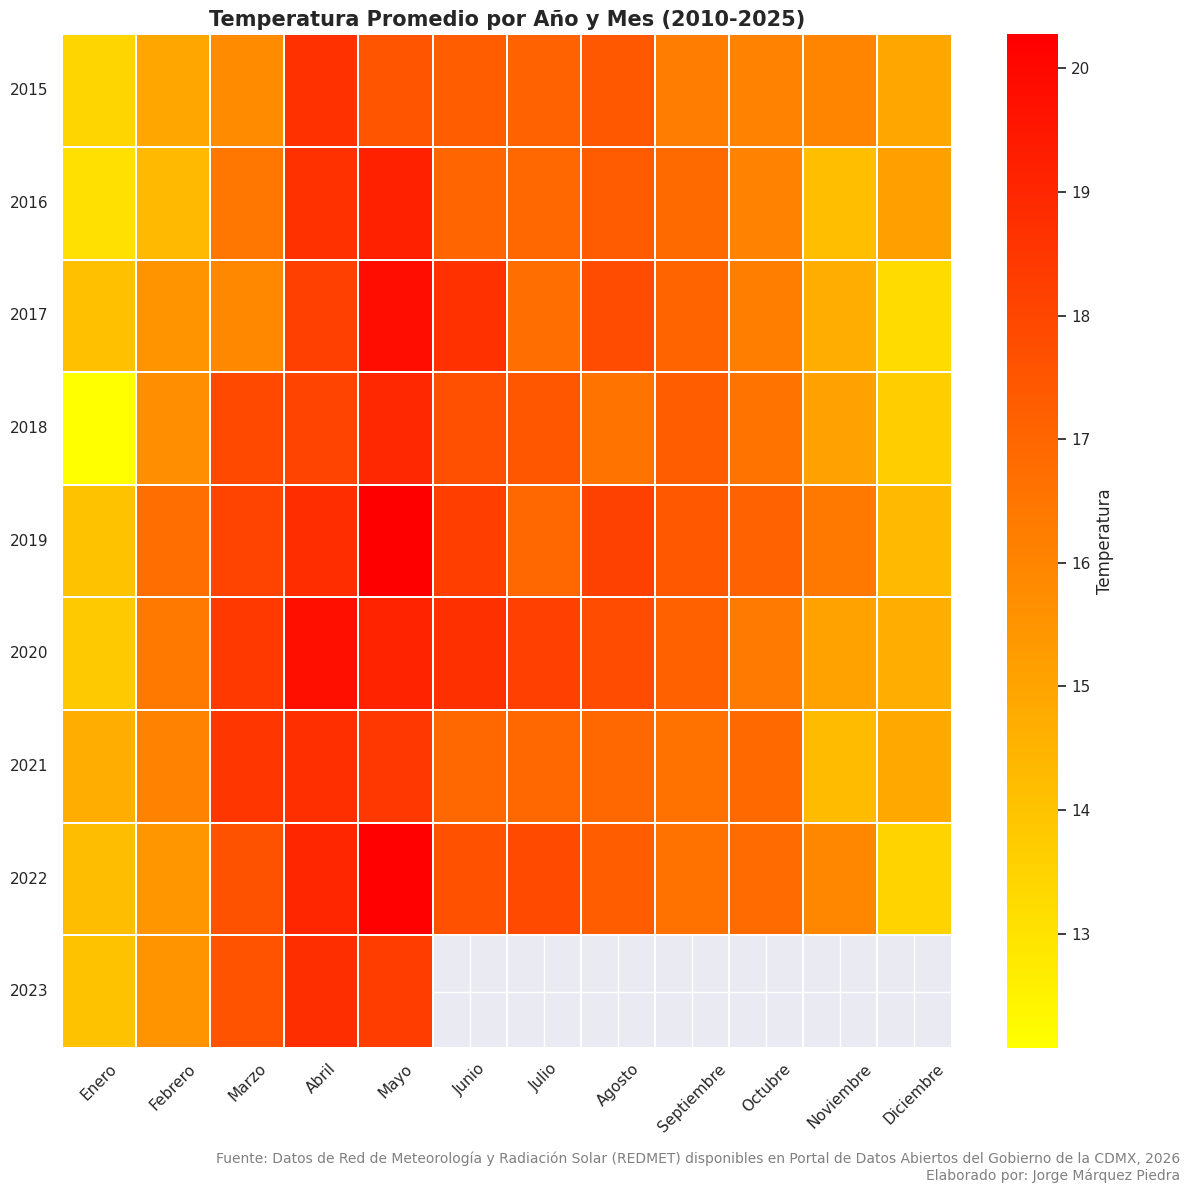

In [28]:
# Heatmap de temperatura promedio por mes y año
pivot = redmet.pivot_table(values = 'TMP', index = 'año', columns = 'mes', aggfunc = 'mean')

orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
#orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

# Ordenar los meses para el mapa
pivot = pivot[orden_meses]

plt.figure(figsize=(12, 12))
sns.set_theme()
sns.heatmap(pivot, cmap = "autumn_r", fmt = ".0f", linewidths = 0.1, cbar_kws = {'label': 'Temperatura'})
plt.title('Temperatura Promedio por Año y Mes (2010-2025)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45)
plt.yticks(rotation = 0)
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('heatmap_temp_año_mes.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

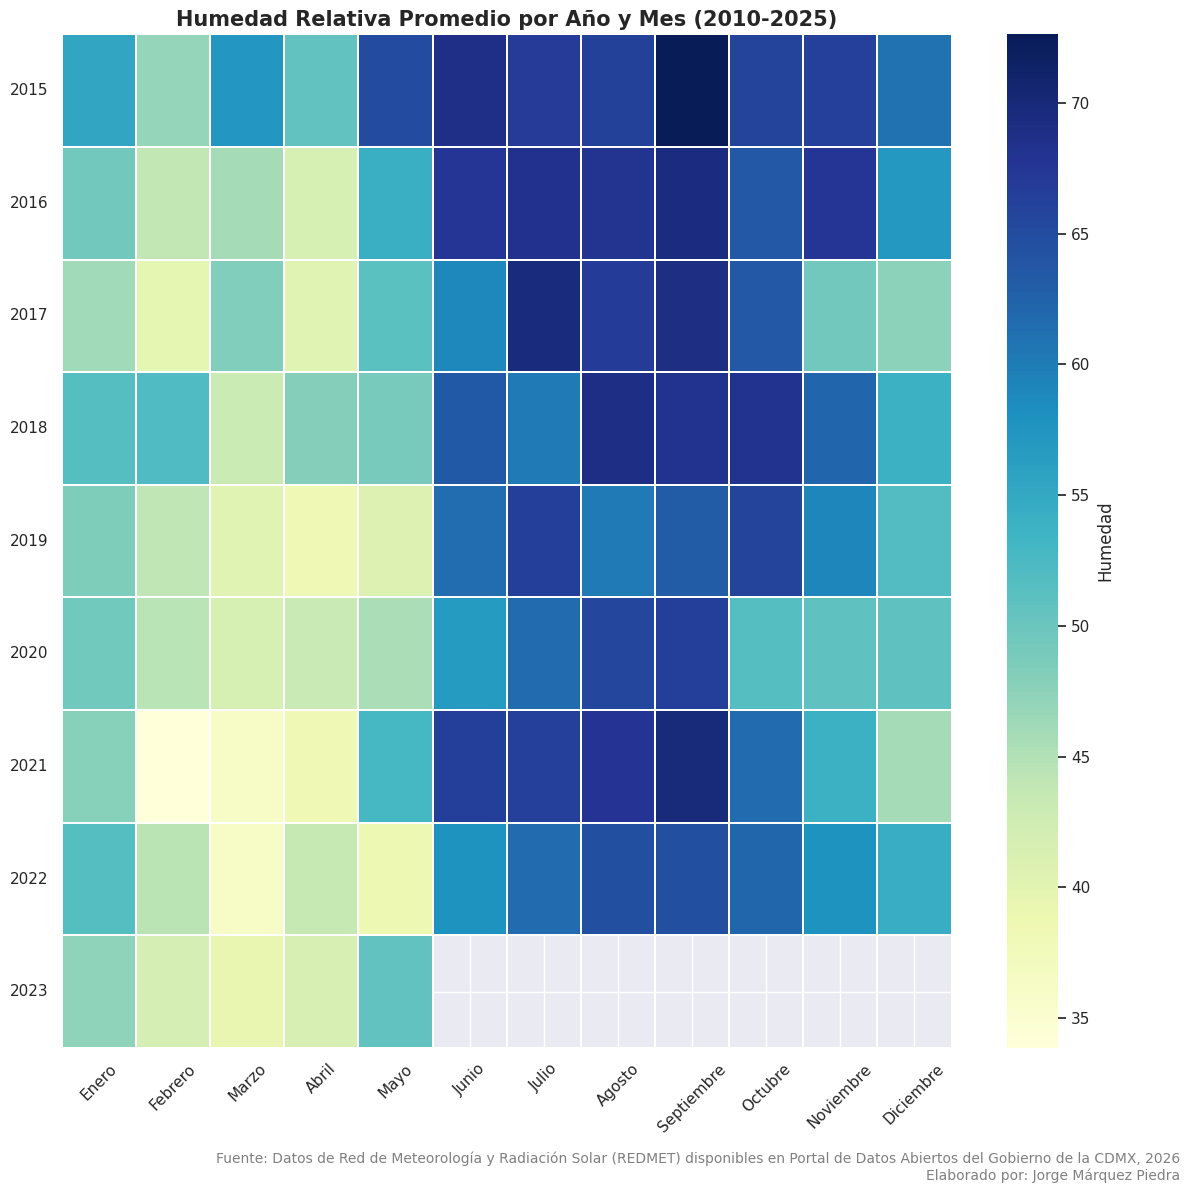

In [29]:
# Heatmap de humedad relativa promedio por mes y año
pivot = redmet.pivot_table(values = 'RH', index = 'año', columns = 'mes', aggfunc = 'mean')

orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
#orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

# Ordenar los meses para el mapa
pivot = pivot[orden_meses]

plt.figure(figsize=(12, 12))
sns.set_theme()
sns.heatmap(pivot, cmap = 'YlGnBu', fmt = ".0f", linewidths = 0.1, cbar_kws = {'label': 'Humedad'})
plt.title('Humedad Relativa Promedio por Año y Mes (2010-2025)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45)
plt.yticks(rotation = 0)
plt.figtext(0.99, 0.01, 'Fuente: Datos de Red de Meteorología y Radiación Solar (REDMET) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('heatmap_humedad_año_mes.png', dpi = 300)
plt